In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
from scipy.fft import fft, fftfreq
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/Probe_analysis')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Vertical velocity from PIV analysis
## Made from `/PIV/plate_top_rectangular_IR/...`
* IR: 16 x 32 px
* Overlap = 50%
* SA = 16 x 32 px
* stepsize = 3, 5, 7
* sig2noise threshold = 1.2
* max_iter = 10
* kernel_size = 2

In [2]:
base_path = '/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/'
# Results from PIV processing
# 16 x 32 window size, dt = 3, 5, 7 frames, respectively for the three amplitudes
piv_a03_r1 = xr.open_dataset(base_path + 'f14a03_rec_res_r1.nc')
piv_a03_r2 = xr.open_dataset(base_path + 'f14a03_rec_res_r2.nc')
piv_a03_r3 = xr.open_dataset(base_path + 'f14a03_rec_res_r3.nc')

piv_a02_r1 = xr.open_dataset(base_path + 'f14a02_rec_res_r1.nc')
piv_a02_r2 = xr.open_dataset(base_path + 'f14a02_rec_res_r2.nc')
piv_a02_r3 = xr.open_dataset(base_path + 'f14a02_rec_res_r3.nc')

piv_a01_r1 = xr.open_dataset(base_path + 'f14a01_rec_res_r1.nc')
piv_a01_r2 = xr.open_dataset(base_path + 'f14a01_rec_res_r2.nc')
piv_a01_r3 = xr.open_dataset(base_path + 'f14a01_rec_res_r3.nc')

base_path = '/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/'
# Results from probe analysis
no_plates_20 = pd.read_csv(base_path + 'no_plates_20cm.csv')
plates_20 = pd.read_csv(base_path + 'plates_20cm.csv')

f14a03 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.3)]
f14a02 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.2)]
f14a01 = no_plates_20[(no_plates_20["frequency"] == 1.4) & (no_plates_20["volt"] == 0.1)]

f14a03_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.3)]
f14a02_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.2)]
f14a01_p = plates_20[(plates_20["frequency"] == 1.4) & (plates_20["volt"] == 0.1)]

del no_plates_20, plates_20

## Observed values

In [3]:
piv_a01_r1

<xarray.Dataset> Size: 6MB
Dimensions:    (time: 37, z: 50, x: 76)
Coordinates:
  * time       (time) float64 296B 20.06 20.11 20.17 20.22 ... 21.96 22.02 22.07
  * x          (x) float64 608B 0.002726 0.005452 0.008178 ... 0.2045 0.2072
  * z          (z) float64 400B 0.001363 0.002726 0.004089 ... 0.06679 0.06815
Data variables:
    u          (time, z, x) float64 1MB ...
    w          (time, z, x) float64 1MB ...
    vorticity  (time, z, x) float64 1MB ...
    dudx       (time, z, x) float64 1MB ...
    dwdz       (time, z, x) float64 1MB ...
Attributes:
    description:      PIV results: full velocity fields and values along plat...
    units_u:          m s-1
    units_w:          m s-1
    units_vorticity:  s-1
    units_dudx:       s-1
    units_dwdz:       s-1
    plate_top_m:      0.0584421906693712
    y_idx_plate_top:  42

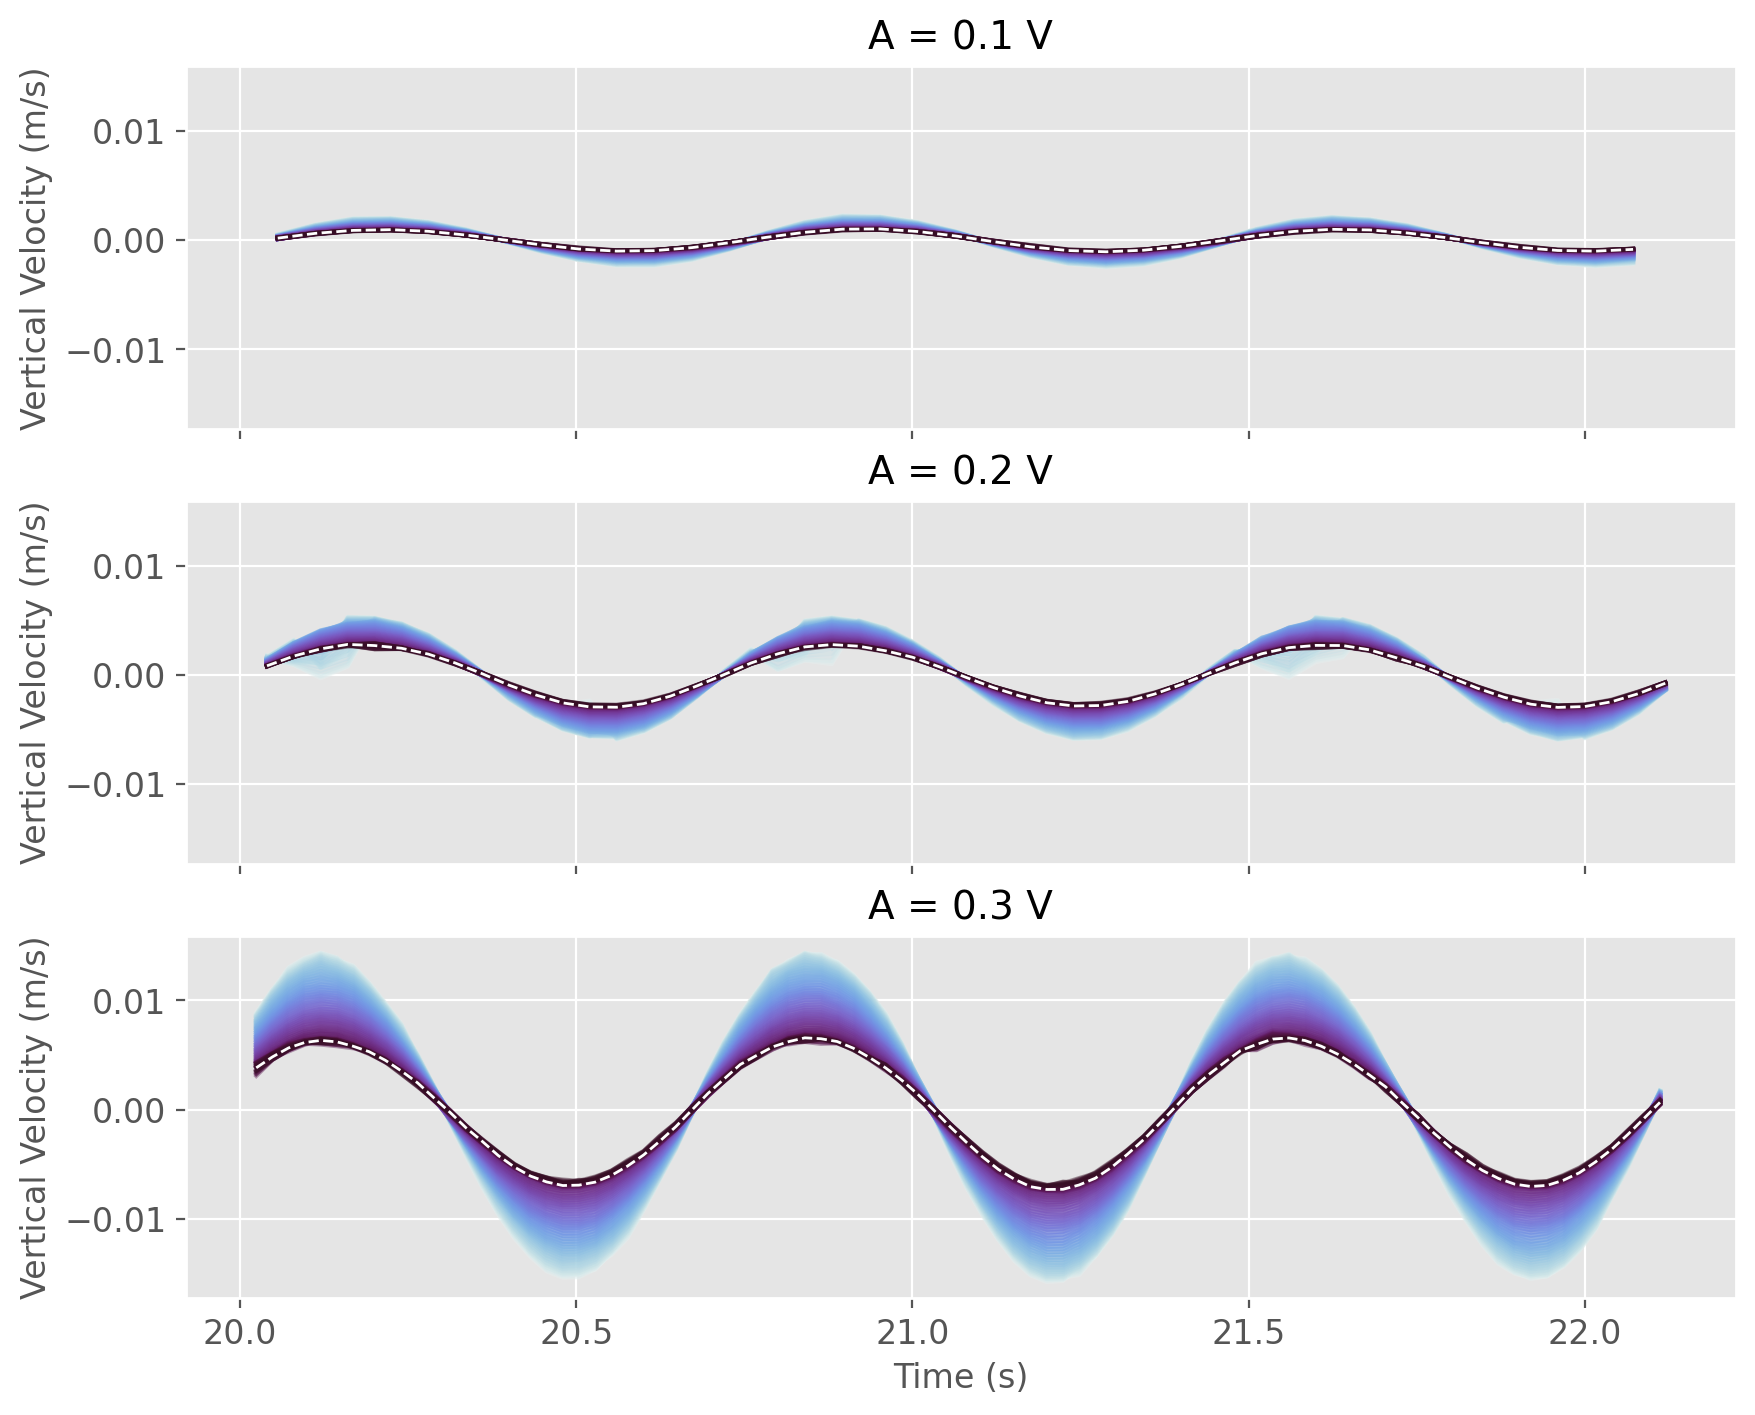

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharey=True, sharex=True)

# choose a colormap
cmap = cmo.dense
N = 50  # number of lines per subplot

for i in range(N):
    # normalize i to [0, 1] to sample from the colormap
    t = i / (N - 1)
    color = cmap(t)

    # A = 0.1 V
    ax[0].plot(piv_a01_r1.time, piv_a01_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r2.time, piv_a01_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r3.time, piv_a01_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.2 V
    ax[1].plot(piv_a02_r1.time, piv_a02_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r2.time, piv_a02_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r3.time, piv_a02_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.3 V
    ax[2].plot(piv_a03_r1.time, piv_a03_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r2.time, piv_a03_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r3.time, piv_a03_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    
a01_mean = np.mean([piv_a01_r1['w'].mean(axis=2)[:, 42], piv_a01_r2['w'].mean(axis=2)[:, 42], piv_a01_r3['w'].mean(axis=2)[:, 42]], axis=0)
a02_mean = np.mean([piv_a02_r1['w'].mean(axis=2)[:, 42], piv_a02_r2['w'].mean(axis=2)[:, 42], piv_a02_r3['w'].mean(axis=2)[:, 42]], axis=0)
a03_mean = np.mean([piv_a03_r1['w'].mean(axis=2)[:, 42], piv_a03_r2['w'].mean(axis=2)[:, 42], piv_a03_r3['w'].mean(axis=2)[:, 42]], axis=0)

ax[0].plot(piv_a01_r1.time, a01_mean, color='white', linestyle='--', linewidth=1, label='Mean')
ax[1].plot(piv_a02_r1.time, a02_mean, color='white', linestyle='--', linewidth=1, label='Mean')
ax[2].plot(piv_a03_r1.time, a03_mean, color='white', linestyle='--', linewidth=1, label='Mean')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')
ax[2].set_xlabel('Time (s)')

for a in ax:
    a.set_ylabel('Vertical Velocity (m/s)')


## The theoretical values
#### Damping coefficient
$\alpha_{theory} = \alpha_{Weber}/(1 + Q)$ 

$Q = \frac{(3 - D/H)gDh^4k^2}{288\nu^2}$ 

$ \alpha_{Weber} = kh^2\omega(D-H)/(24H\nu)$ 

#### Robin parameter
$R_{theory} = (2H\alpha_{theory})/k$

#### Vertical velocity at z = -H

$\operatorname{Re}\{\bar{w}(z=-H)\} = -gh^2(D-H)Ae^{-\alpha x} \frac{\beta}{144\nu^2 + h^4\omega^2}$

where A is the real amplitude of the free surface ($\eta$) and, $\beta = 12\nu(k^2\cos\theta - 2\alpha k\sin\theta) - h^2\omega(k^2\sin\theta + 2\alpha k\cos\theta)$ with the phase $\theta = kx -\omega t$.

In [5]:
start = piv_a03_r1.time.values[0]
end = piv_a03_r1.time.values[-1]
time_piv = piv_a03_r1.time.values

In [6]:
f = 1.4  # frequency (Hz)
omega = 2 * np.pi * f  # angular frequency (rad/s)
g = 9.81  # gravitational acceleration (m/s^2)
nu = 1e-6  # kinematic viscosity of water (m^2/s)
D = 0.2  # water height (m)
H = 0.15  # depth of plate top (m)
h = 0.01  # distance between plates (m)
k = estimate_wavenumber(f, D)

a_theory, a_weber = spatial_damping_coefficient(k, D, H, h)

# Robin parameter
R_theory = robin_parameter(H, a_theory, k)
R_weber = robin_parameter(H, a_weber, k)

In [7]:
A01 = np.mean([np.mean(f14a01['amp_P0']), np.mean(f14a01_p['amp_P0'])])
A02 = np.mean([np.mean(f14a02['amp_P0']), np.mean(f14a02_p['amp_P0'])])
A03 = np.mean([np.mean(f14a03['amp_P0']), np.mean(f14a03_p['amp_P0'])])

In [8]:
x_probe_pos = np.array([4.86, 6.69, 7.87, 9.15])

In [9]:
x = 8.06 - x_probe_pos[0]
t = time_piv

# Vertical velocity at z=-H
w_bar_theory_a03 = vertical_velocity(A03, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a02 = vertical_velocity(A02, D, H, f, a_theory, k, h, x, t)
w_bar_theory_a01 = vertical_velocity(A01, D, H, f, a_theory, k, h, x, t)

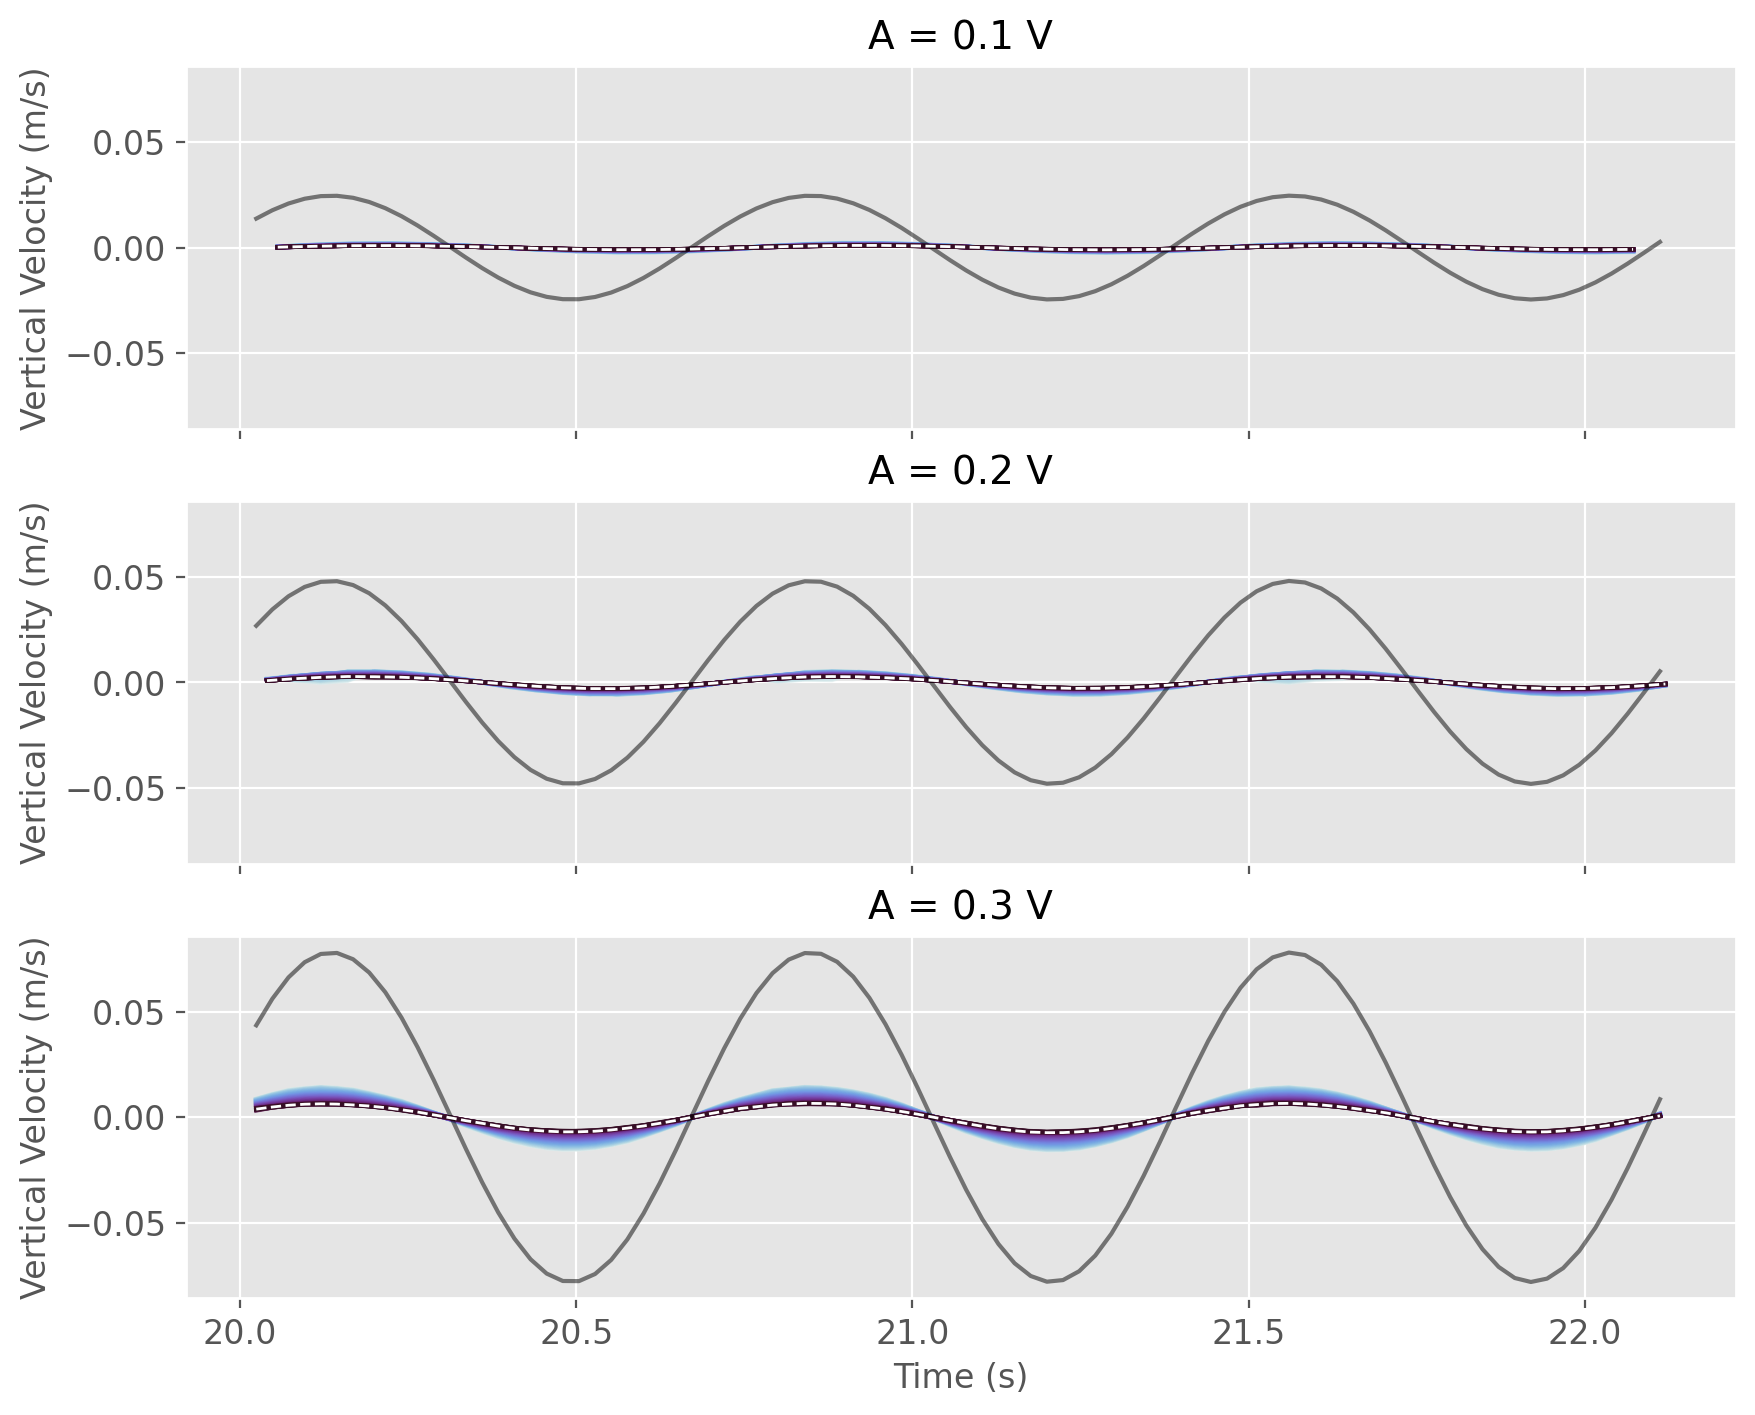

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharey=True, sharex=True)

# choose a colormap
cmap = cmo.dense
N = 50  # number of lines per subplot

for i in range(N):
    # normalize i to [0, 1] to sample from the colormap
    t = i / (N - 1)
    color = cmap(t)

    # A = 0.1 V
    ax[0].plot(piv_a01_r1.time, piv_a01_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r2.time, piv_a01_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[0].plot(piv_a01_r3.time, piv_a01_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.2 V
    ax[1].plot(piv_a02_r1.time, piv_a02_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r2.time, piv_a02_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[1].plot(piv_a02_r3.time, piv_a02_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)

    # A = 0.3 V
    ax[2].plot(piv_a03_r1.time, piv_a03_r1['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r2.time, piv_a03_r2['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    ax[2].plot(piv_a03_r3.time, piv_a03_r3['w'].mean(axis=2)[:, i],
               color=color, alpha=0.4)
    
a01_mean = np.mean([piv_a01_r1['w'].mean(axis=2)[:, 42], piv_a01_r2['w'].mean(axis=2)[:, 42], piv_a01_r3['w'].mean(axis=2)[:, 42]], axis=0)
a02_mean = np.mean([piv_a02_r1['w'].mean(axis=2)[:, 42], piv_a02_r2['w'].mean(axis=2)[:, 42], piv_a02_r3['w'].mean(axis=2)[:, 42]], axis=0)
a03_mean = np.mean([piv_a03_r1['w'].mean(axis=2)[:, 42], piv_a03_r2['w'].mean(axis=2)[:, 42], piv_a03_r3['w'].mean(axis=2)[:, 42]], axis=0)

ax[0].plot(time_piv, w_bar_theory_a01, color='black', alpha=0.5)
ax[1].plot(time_piv, w_bar_theory_a02, color='black', alpha=0.5)
ax[2].plot(time_piv, w_bar_theory_a03, color='black', alpha=0.5)

ax[0].plot(piv_a01_r1.time, a01_mean, color='white', linestyle='--', linewidth=1, label='Mean')
ax[1].plot(piv_a02_r1.time, a02_mean, color='white', linestyle='--', linewidth=1, label='Mean')
ax[2].plot(piv_a03_r1.time, a03_mean, color='white', linestyle='--', linewidth=1, label='Mean')

ax[0].set_title('A = 0.1 V')
ax[1].set_title('A = 0.2 V')
ax[2].set_title('A = 0.3 V')
ax[2].set_xlabel('Time (s)')

for a in ax:
    a.set_ylabel('Vertical Velocity (m/s)')
